In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [4]:
data=[
  {"CustomerID": 1, "Income": 15, "SpendingScore": 39},
  {"CustomerID": 2, "Income": 16, "SpendingScore": 81},
  {"CustomerID": 3, "Income": 17, "SpendingScore": 6},
  {"CustomerID": 4, "Income": 18, "SpendingScore": 77},
  {"CustomerID": 5, "Income": 19, "SpendingScore": 40},
  {"CustomerID": 6, "Income": 20, "SpendingScore": 76},
  {"CustomerID": 7, "Income": 21, "SpendingScore": 6},
  {"CustomerID": 8, "Income": 22, "SpendingScore": 94},
  {"CustomerID": 9, "Income": 23, "SpendingScore": 3},
  {"CustomerID": 10, "Income": 24, "SpendingScore": 72}
]

df=pd.DataFrame(data)
display(df.head())

,CustomerID,Income,SpendingScore
0,1,15,39
1,2,16,81
2,3,17,6
3,4,18,77
4,5,19,40


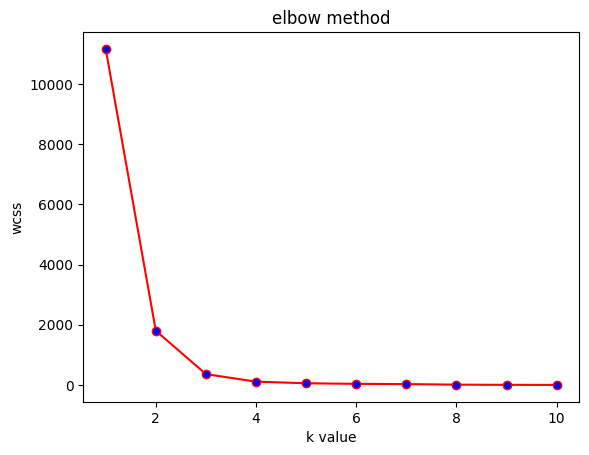

In [8]:
wcss=[]
for i in range(1,11):
    wcss.append(KMeans(n_clusters=i,random_state=42).fit(df[["Income","SpendingScore"]]).inertia_)
plt.plot(range(1,11),wcss,'r-o',mfc='b')
plt.xlabel("k value")
plt.ylabel("wcss")
plt.title("elbow method")
plt.show()

In [10]:
kmeans=KMeans(n_clusters=3,random_state=42)
prediction=kmeans.fit_predict(df[["Income","SpendingScore"]])
print(prediction)

[2 0 1 0 2 0 1 0 1 0]


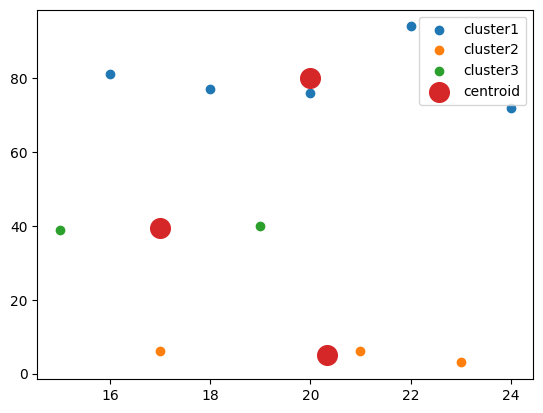

In [24]:
cluster_name=["cluster1","cluster2","cluster3"]
x=df[["Income","SpendingScore"]].values
for i in range(3):
    plt.scatter(x[prediction==i,0],x[prediction==i,1],label=cluster_name[i])
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],label="centroid",s=200)
plt.legend()
plt.show()

In [21]:
from sklearn.metrics import silhouette_score

# Calculate silhouette score
score = silhouette_score(x, prediction)

print("Silhouette Score:", score)

Silhouette Score: 0.8008063633751474
